# Report - operator-level optimization

Assembles the figures across experiments. Each section states the claim, shows the
evidence, and names what would falsify it.

Run the sweeps in `configs/experiments/` first; each notebook `e0*.ipynb` covers one in
more detail.

In [1]:
%load_ext autoreload
%autoreload 2
import matplotlib.pyplot as plt
from olo.viz import (load_runs, lr_grid, convergence, depth_wall, mismatch_vs_depth,
                     spectrum, cost, best_per, apply_style)

apply_style()
runs = {name: load_runs("../runs", f"{name}*") for name in
        ("e01_deep_linear_identity", "e02_depth_wall", "e02_relu_xavier",
         "e03_mismatch_vs_depth", "e04_implicit_bias", "e05_mnist_depth")}
for k, v in runs.items():
    print(f"{k:28s} {len(v):4d} runs")

e01_deep_linear_identity        0 runs
e02_depth_wall                  1 runs
e02_relu_xavier                 0 runs
e03_mismatch_vs_depth           1 runs
e04_implicit_bias               1 runs
e05_mnist_depth                 1 runs


## 1. The mismatch is generated by training, not by initialization

At an orthogonal initialization every context is orthogonal, so Proposition 3.1 gives
`sum_k A_k A_k^T G B_k^T B_k = L G` -- exactly parallel to `G`. There is no direction
mismatch at step 0 at any depth. Gradient descent then *creates* the misalignment, and
depth sets how fast.

This corrects the submitted paper's appendix, which attributed the Haar-init failure to
orientation-induced mismatch present at initialization.

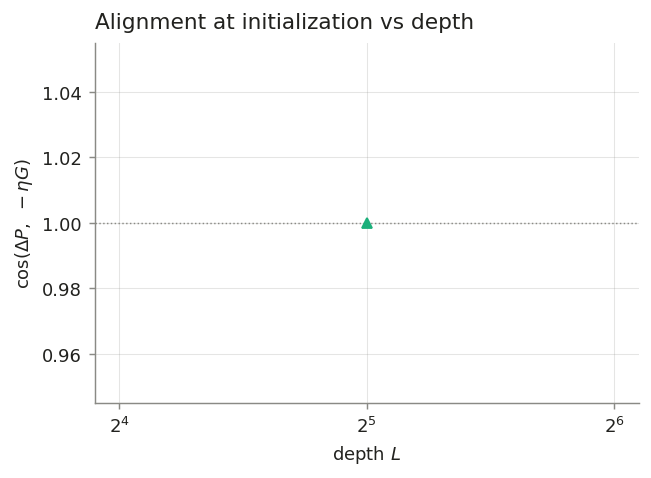

In [2]:
r3 = runs["e03_mismatch_vs_depth"]
if r3:
    fig, ax = plt.subplots(figsize=(5.4, 3.6))
    mismatch_vs_depth(r3, ax=ax, title="Alignment at initialization vs depth")
    fig.savefig("../figures/report_mismatch_vs_depth.pdf")

## 2. Conditioning is removable by parameterization

CReLU with a looks-linear initialization has an exactly orthogonal Jacobian at every depth
for every input, with no warm-start. The collapse monitor reads `rho` above threshold for
every layer, where the ReLU/Xavier network flags most of them.

In [3]:
for name in ("e02_relu_xavier", "e02_depth_wall"):
    rs = runs[name]
    if not rs:
        continue
    r = rs[0]
    _, frac = r.series("collapsed_fraction")
    _, cond = r.series("context_cond_max")
    if len(frac):
        print(f"{name:20s} L={r.depth:4d}  collapsed layers {frac[0]:.2f}  "
              f"worst context condition {cond[0]:.3e}")

e02_depth_wall       L=  32  collapsed layers 0.00  worst context condition 1.000e+00


## 3. Once collapse is removed, is a tuned baseline still beaten?

In [4]:
if runs["e02_depth_wall"] and runs["e02_relu_xavier"]:
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
    depth_wall(runs["e02_relu_xavier"], ax=axes[0], title="ReLU, Xavier")
    depth_wall(runs["e02_depth_wall"],  ax=axes[1], title="CReLU, looks-linear")
    fig.tight_layout()
    fig.savefig("../figures/report_depth_wall.pdf")

## 4. Is correcting the factorization bias desirable?

Matrix sensing, underdetermined. Projection uses factored Adam's parameterization while
realizing direct-P Adam's trajectory, so the gap between them is the factorization bias
alone. Here the bias *helps*: it selects a lower-rank operator that generalizes better.

In [5]:
r4 = runs["e04_implicit_bias"]
for r in r4:
    print(f"{r.method:10s} held-out {r.final('eval_held_out_mse'):.3e}  "
          f"eff rank {r.final('eval_effective_rank'):.2f}  "
          f"recovery {r.final('eval_rel_recovery_error'):.3f}")

als        held-out 4.991e-01  eff rank 19.07  recovery 3.172


## 5. Real data

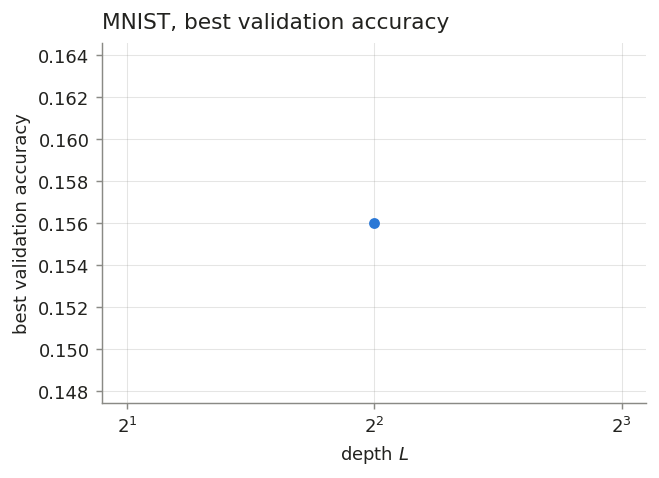

In [6]:
r5 = runs["e05_mnist_depth"]
if r5:
    fig, ax = plt.subplots(figsize=(5.4, 3.6))
    depth_wall(r5, ax=ax, metric="eval_val_accuracy", title="MNIST, best validation accuracy")
    ax.set_yscale("linear")
    fig.savefig("../figures/report_mnist.pdf")